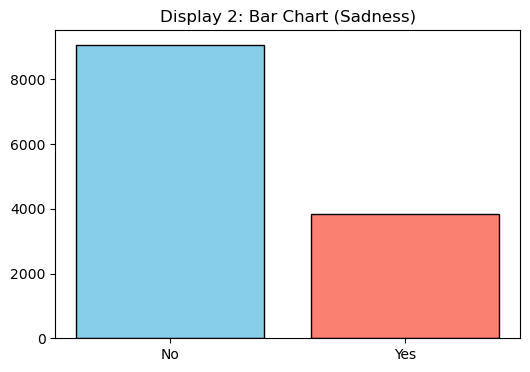

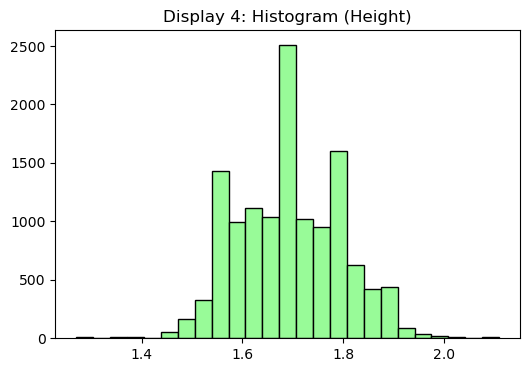

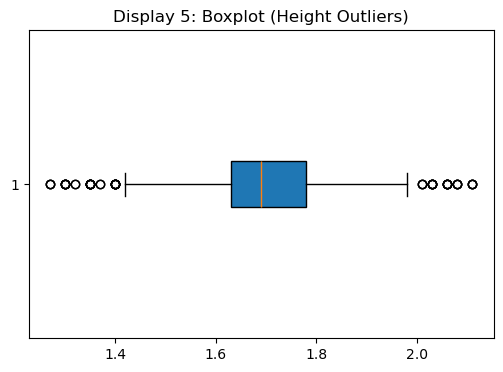

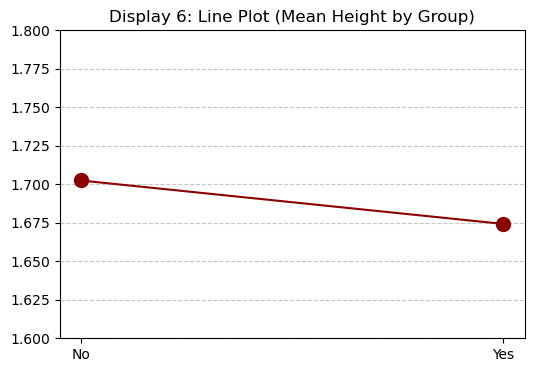

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('data/processed/yrbs_cleaned.csv')

fig_path = 'outputs/figures'
tab_path = 'outputs/tables'

if not os.path.exists(fig_path):
    os.makedirs(fig_path)
if not os.path.exists(tab_path):
    os.makedirs(tab_path)

sad_counts = df['Sad_Binary'].value_counts().sort_index()
sad_table = pd.DataFrame({'Count': sad_counts, 'Proportion': df['Sad_Binary'].value_counts(normalize=True).sort_index()})
sad_table.index = ['No (0)', 'Yes (1)']
sad_table.to_csv(os.path.join(tab_path, 'display1_sadness_table.csv'))

plt.figure(figsize=(6, 4))
plt.bar(['No', 'Yes'], sad_counts, color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Display 2: Bar Chart (Sadness)')
plt.savefig(os.path.join(fig_path, 'behavior_bar_chart.png'))
plt.show()

height_stats = df['HowTallAreYouWithoutShoesInMeters'].describe()
height_stats['median'] = df['HowTallAreYouWithoutShoesInMeters'].median()
height_stats.to_csv(os.path.join(tab_path, 'height_summary_table.csv'))

plt.figure(figsize=(6, 4))
plt.hist(df['HowTallAreYouWithoutShoesInMeters'], bins=25, color='palegreen', edgecolor='black')
plt.title('Display 4: Histogram (Height)')
plt.savefig(os.path.join(fig_path, 'height_histogram.png'))
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(df['HowTallAreYouWithoutShoesInMeters'], vert=False, patch_artist=True)
plt.title('Display 5: Boxplot (Height Outliers)')
plt.savefig(os.path.join(fig_path, 'height_boxplot.png'))
plt.show()

group_means = df.groupby('Sad_Binary')['HowTallAreYouWithoutShoesInMeters'].mean()
plt.figure(figsize=(6, 4))
plt.plot(['No', 'Yes'], group_means.values, marker='o', linestyle='-', markersize=10, color='darkred')
plt.ylim(1.6, 1.8)
plt.title('Display 6: Line Plot (Mean Height by Group)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(fig_path, 'additional_line_plot.png'))
plt.show()

Display 2 (Bar Chart):

Written Observation:
The bar chart illustrates the categorical distribution of sadness in the sample. It shows that approximately 30% of students fall into the "Yes" category, providing a clear visual representation of the prevalence of emotional distress.

Display 4 (Histogram):

Written Observation:
The histogram shows a unimodal and symmetric distribution for height. Most observations are concentrated between 1.6m and 1.8m, suggesting the data follows a normal distribution pattern common in biological measurements.

Display 5 (Boxplot):

Written Observation:
The boxplot effectively highlights the quartiles and potential outliers. The presence of points beyond the whiskers indicates that there are extreme height values in the dataset, which represent natural diversity among high school students.

Display 6 (Line Plot ):

Written Observation:
For the additional exploration, a line plot is used to compare the mean height between the two groups. It shows a slight downward trend in mean height for the "Yes" (sadness) group, providing a different perspective on the relationship between emotional state and physical height